# 📈 Real-Time Stock Market Analysis and Prediction using Python

## Project Overview
This project analyzes real-time stock market data of major companies using Python.  
The stock data is collected using the Yahoo Finance API (`yfinance`) and analyzed using data science techniques.

The project includes:
- Real-time stock data collection
- Data preprocessing
- Stock price visualization
- Risk vs Return analysis
- Next-day stock price prediction using Machine Learning

### Technologies Used
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- yFinance

## Step 1: Import Required Libraries

In this step, we import all required Python libraries for:
- Data collection
- Data manipulation
- Machine learning
- Visualization

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from datetime import datetime,timedelta
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Step 2: Select Companies for Analysis

We selected 10 major companies from different sectors:

### Technology
- Apple (AAPL)
- Microsoft (MSFT)
- Google (GOOGL)
- Amazon (AMZN)
- Tesla (TSLA)
- NVIDIA (NVDA)

### Banking
- JPMorgan Chase (JPM)
- Goldman Sachs (GS)

### Retail & Consumer
- Walmart (WMT)
- Coca-Cola (KO)

In [4]:
company_symbols=['AAPL','MSFT','GOOGL','AMZN','TSLA','NVDA','JPM','GS','WMT','KO']
end_date = datetime.now()
start_date = end_date - timedelta(days=365)
print(start_date)

2025-07-02 03:06:22.803052


## Step 3: Collect Real-Time Stock Data

Stock market data is collected from Yahoo Finance using the `yfinance` library.

We collect:
- Open Price
- High Price
- Low Price
- Close Price
- Volume

Time period:
- Last 1 year

In [5]:
company_data = {}

for symbol in company_symbols:
  df = yf.download(symbol, start=start_date, end=end_date)
  company_data[symbol] = df

/tmp/ipykernel_701/518853580.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_701/518853580.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_701/518853580.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_701/518853580.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_701/518853580.py:4: F

## Step 4: Display Collected Data

The dataset for each company contains daily stock market information including price and trading volume.

In [6]:
company_data

{'AAPL': Price            Close        High         Low        Open     Volume
 Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
 Date                                                                 
 2025-07-02  211.600555  212.496993  207.317544  208.084505   67941800
 2025-07-03  212.706146  213.801790  210.973016  211.311669   34955800
 2025-07-07  209.120361  215.375544  207.974912  211.839569   50229000
 2025-07-08  209.180145  210.594532  207.626312  209.269801   42848900
 2025-07-09  210.305664  210.494916  206.401156  208.702025   48749400
 ...                ...         ...         ...         ...        ...
 2026-06-25  275.149994  288.799988  273.750000  287.399994  107013700
 2026-06-26  283.779999  285.950012  274.209991  275.000000  261775500
 2026-06-29  281.739990  288.369995  279.850006  286.730011   66427000
 2026-06-30  289.359985  289.940002  280.700012  281.170013   65100200
 2026-07-01  294.380005  296.589996  289.195007  293.329987   5004659

In [7]:
df

Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2025-07-02,68.957085,69.851745,68.791761,69.715602,13050200
2025-07-03,69.384964,69.433590,68.509749,69.083504,9440500
2025-07-07,69.054329,69.404415,68.850113,69.404415,16984700
2025-07-08,68.305527,68.733411,67.955441,68.733411,17115500
2025-07-09,67.566467,68.315258,67.070511,68.227740,33704100
...,...,...,...,...,...
2026-06-25,80.419998,81.379997,79.970001,80.529999,16021400
2026-06-26,82.629997,82.809998,80.699997,80.959999,53357500


## Step 5: Build Machine Learning Model

We use **Linear Regression** to predict the next day’s stock closing price.

### Input Feature:
- Current Closing Price

### Target:
- Next Day Closing Price

In [8]:
company_models={}
for symbol, df in company_data.items():
  df =df.copy()
  df['Target'] = df['Close'].shift(-1)
  df.dropna(inplace=True)
  x=df[['Close']]
  y=df[['Target']]
  x_train,x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
  model = LinearRegression()
  model.fit(x_train, y_train)
  company_models[symbol] = model


## Step 6: Model Evaluation

To evaluate model performance, we use:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)

Lower values indicate better prediction performance.

In [9]:
for symbol, df in company_data.items():
  model = company_models[symbol]
  x_test = df[['Close']].tail(1)
  y_test = df[['Close']].tail(1)
  y_pred = model.predict(x_test)


  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)

  print(f"Company : {symbol}")
  print(f"MAE: {mae:.2f}")
  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print("\n")

Company : AAPL
MAE: 0.27
MSE: 0.07
RMSE: 0.27


Company : MSFT
MAE: 0.23
MSE: 0.05
RMSE: 0.23


Company : GOOGL
MAE: 0.37
MSE: 0.14
RMSE: 0.37


Company : AMZN
MAE: 0.44
MSE: 0.19
RMSE: 0.44


Company : TSLA
MAE: 0.48
MSE: 0.23
RMSE: 0.48


Company : NVDA
MAE: 0.43
MSE: 0.19
RMSE: 0.43


Company : JPM
MAE: 1.79
MSE: 3.19
RMSE: 1.79


Company : GS
MAE: 1.73
MSE: 2.99
RMSE: 1.73


Company : WMT
MAE: 0.15
MSE: 0.02
RMSE: 0.15


Company : KO
MAE: 0.07
MSE: 0.00
RMSE: 0.07




## Step 7: Closing Price Visualization

This graph shows stock closing price trends over time for each company.

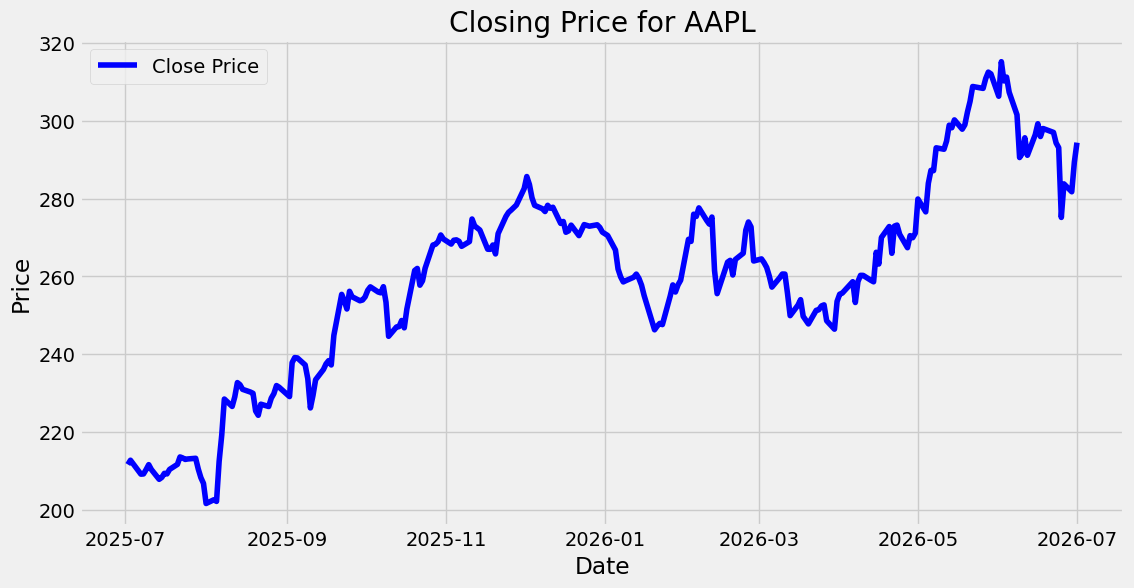

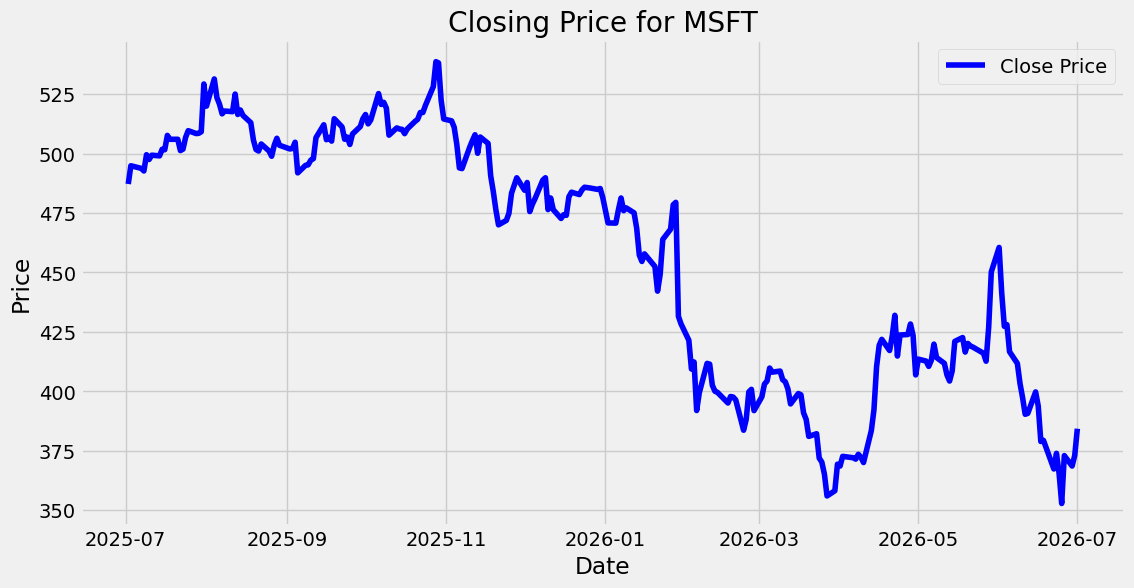

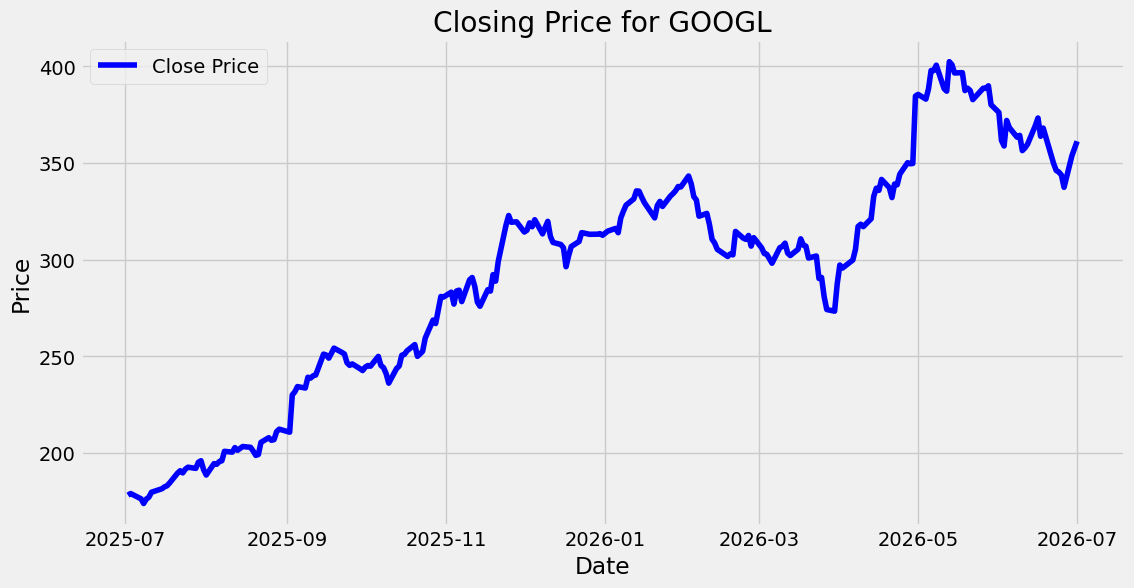

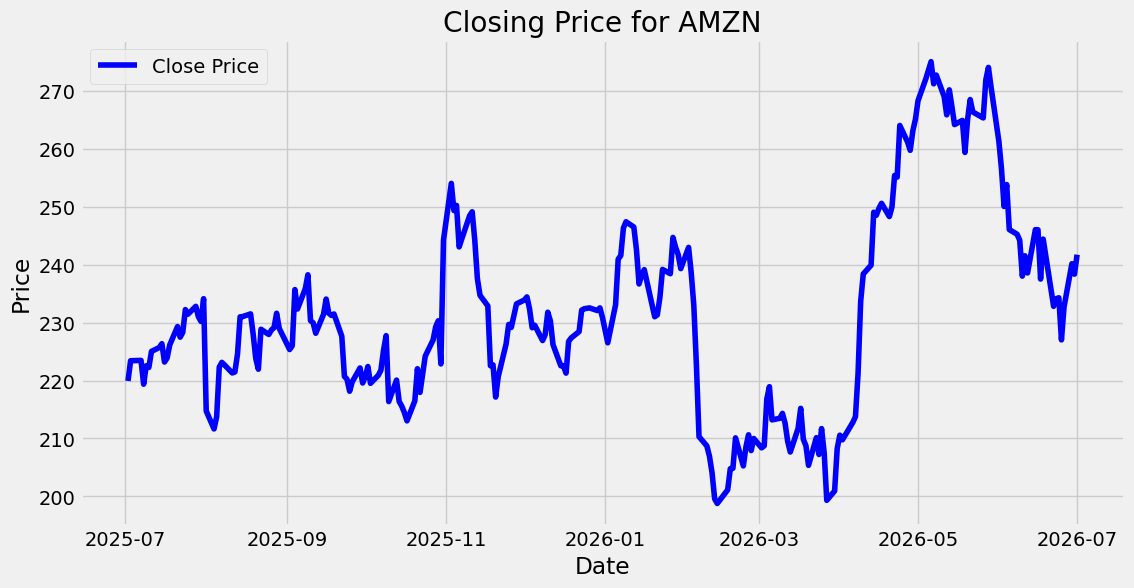

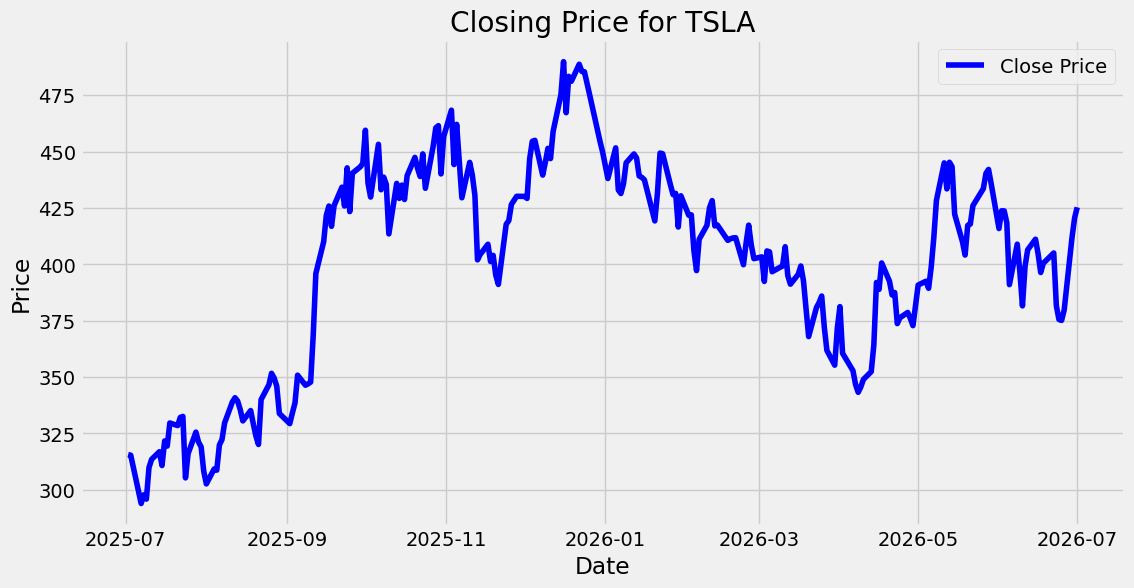

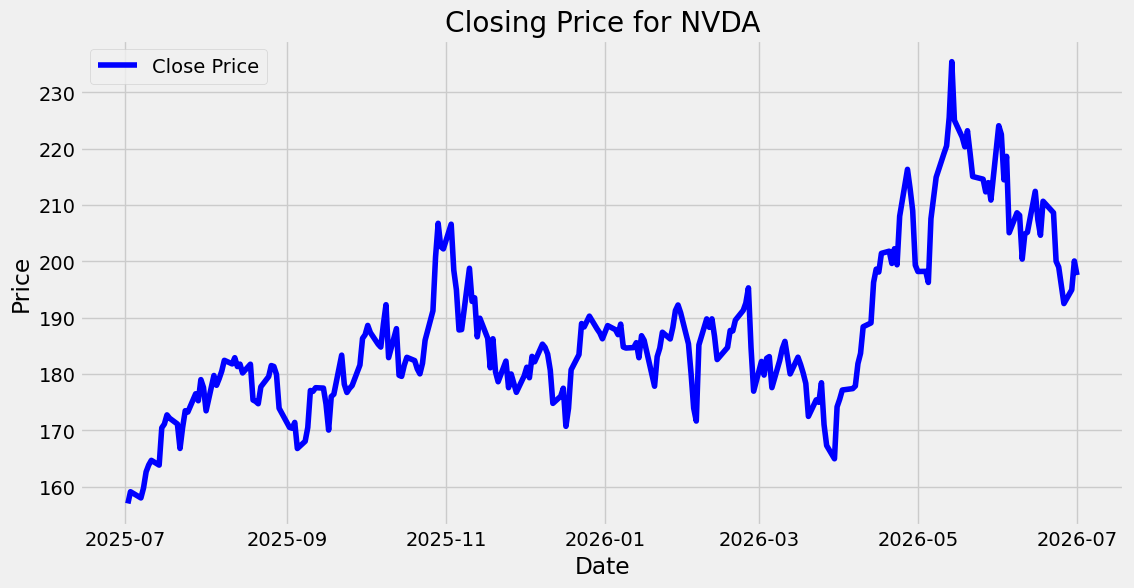

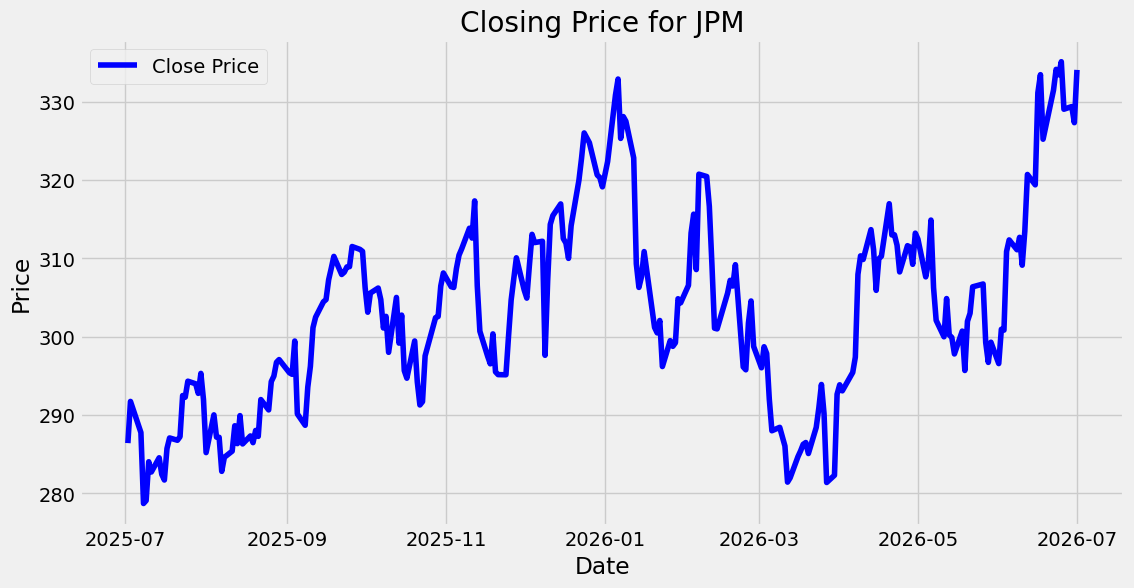

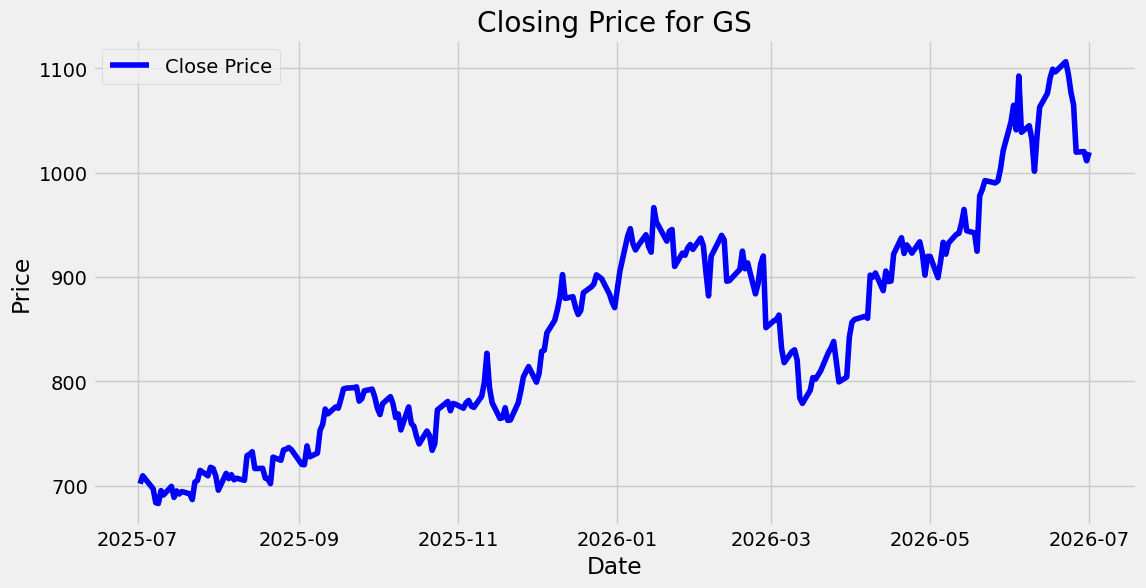

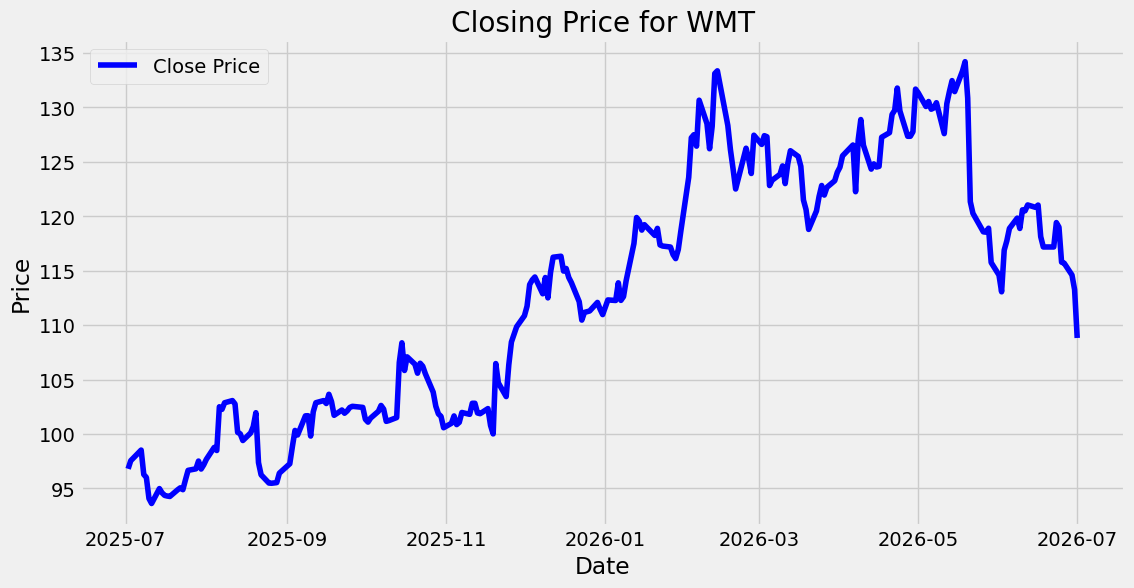

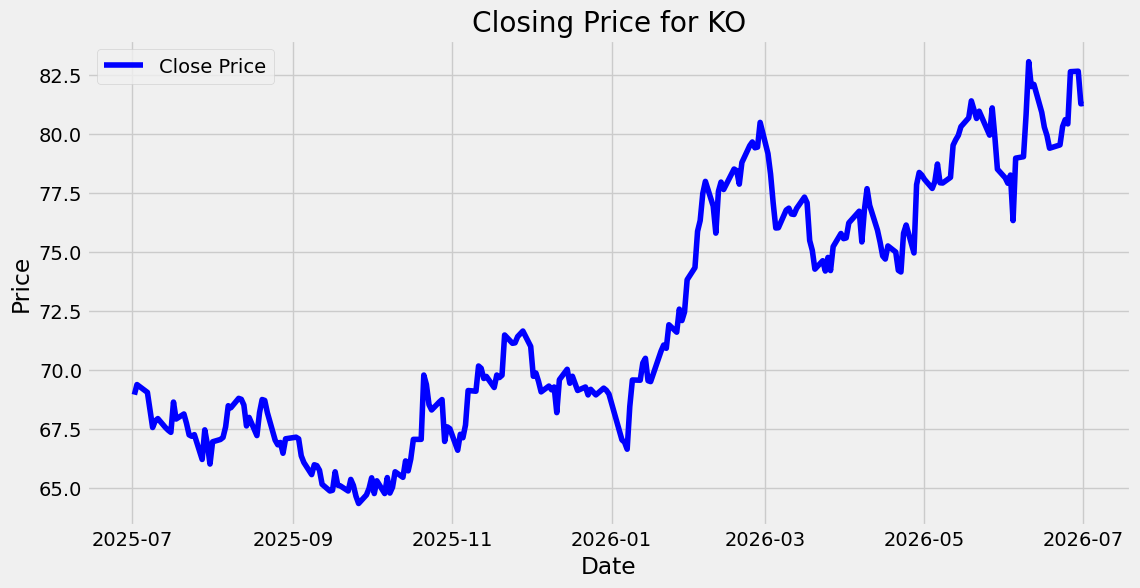

In [10]:
for symbol, df in company_data.items():
  plt.figure(figsize=(12,6))
  plt.plot(df.index, df['Close'], label='Close Price', color='blue')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()
  plt.title(f'Closing Price for {symbol}')
  plt.grid(True)
  plt.show()

## Step 8: Trading Volume Analysis

This graph shows the daily trading volume of each company.

High trading volume indicates strong market activity.

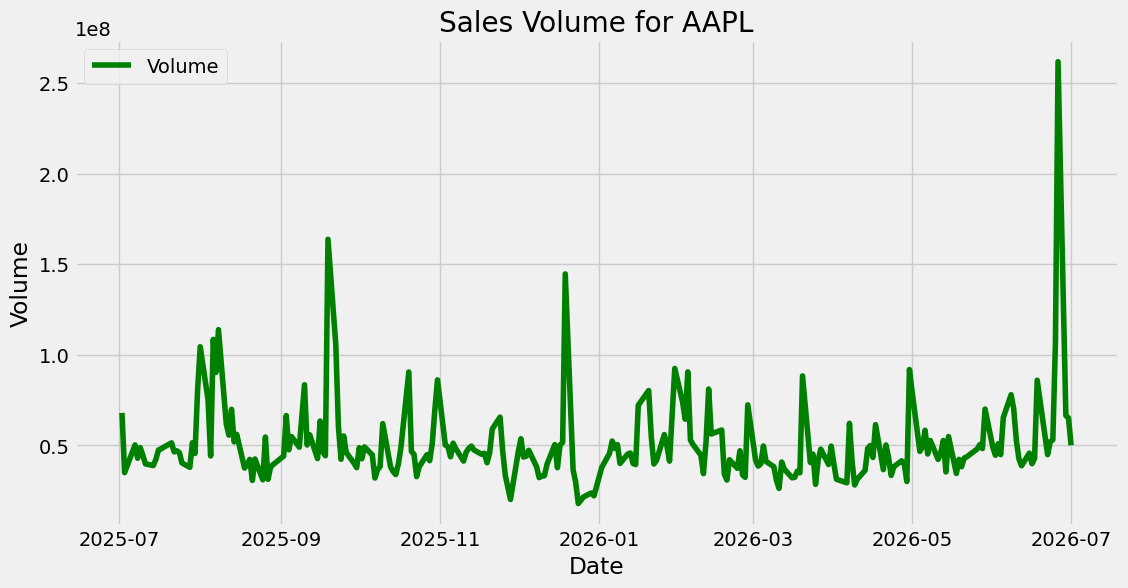

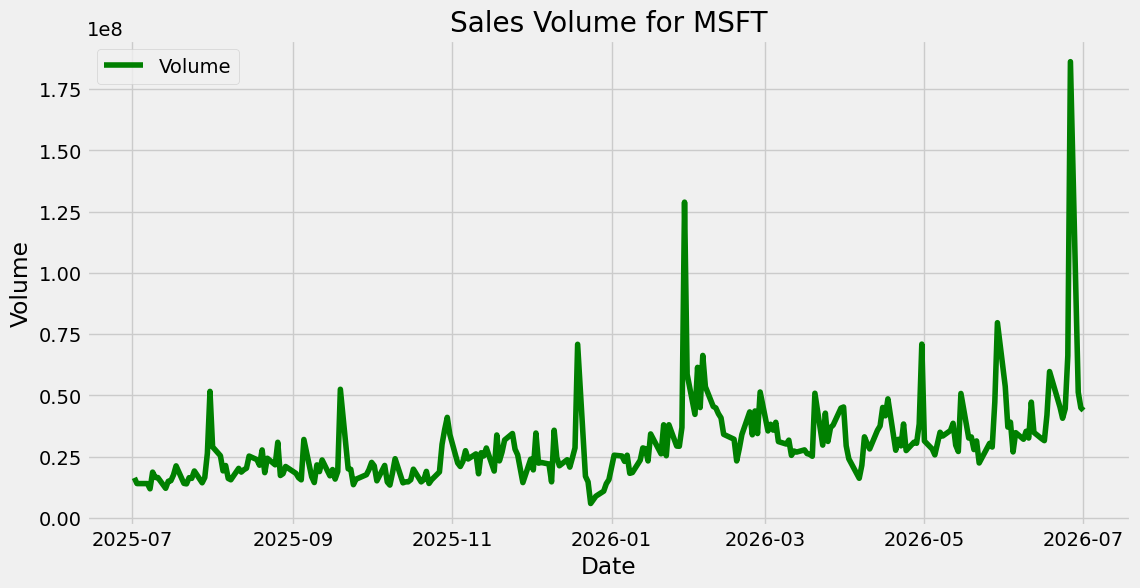

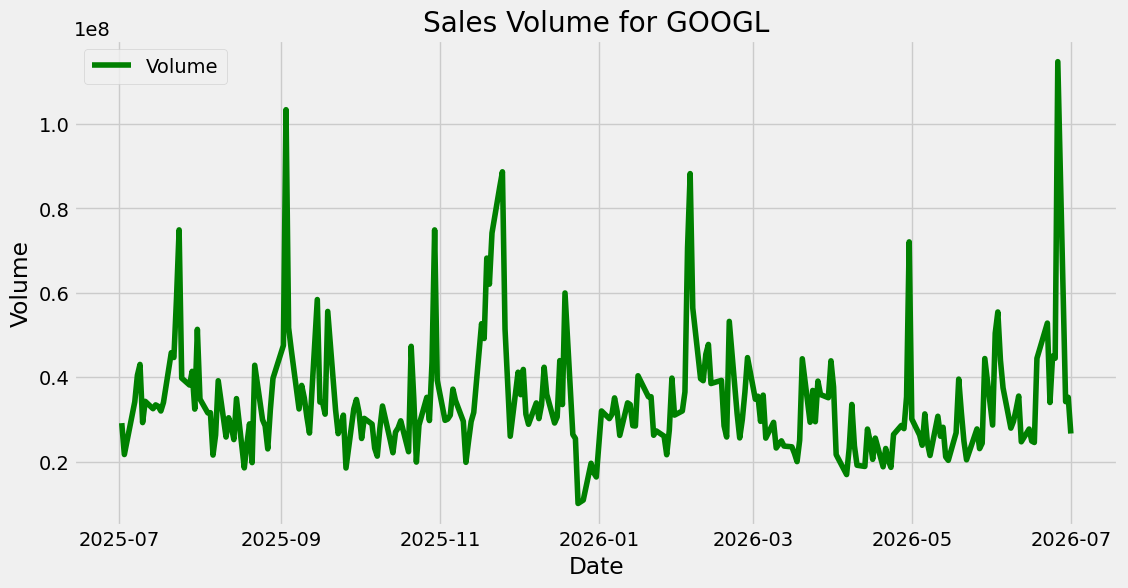

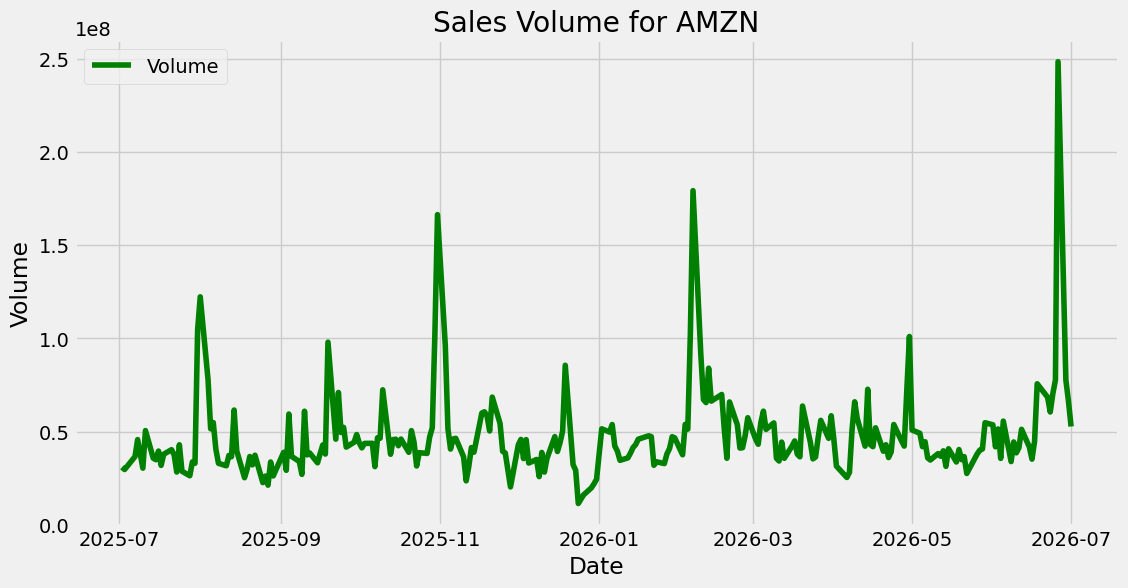

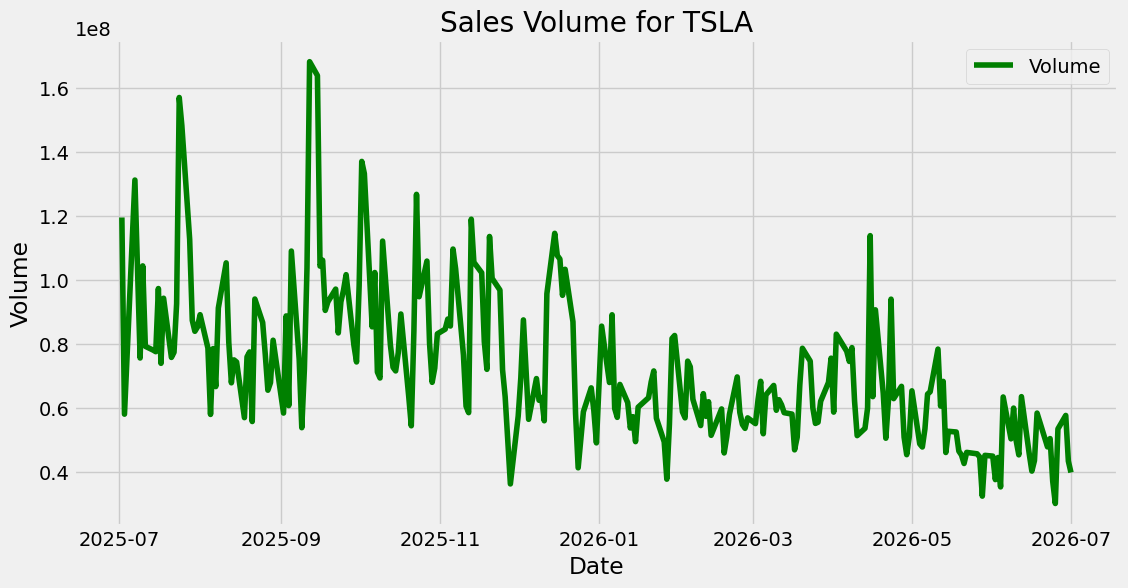

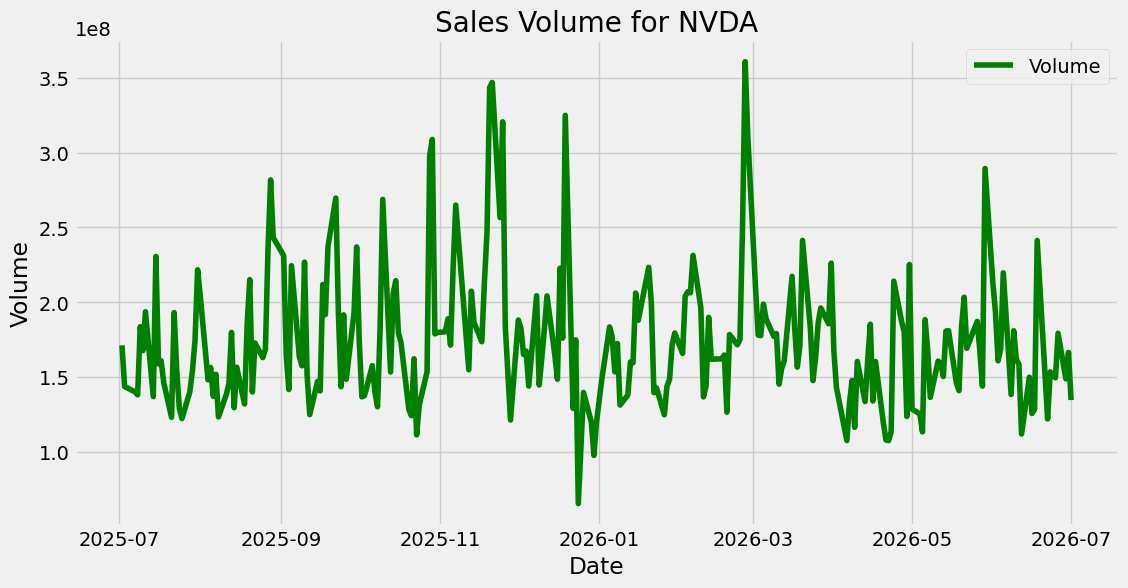

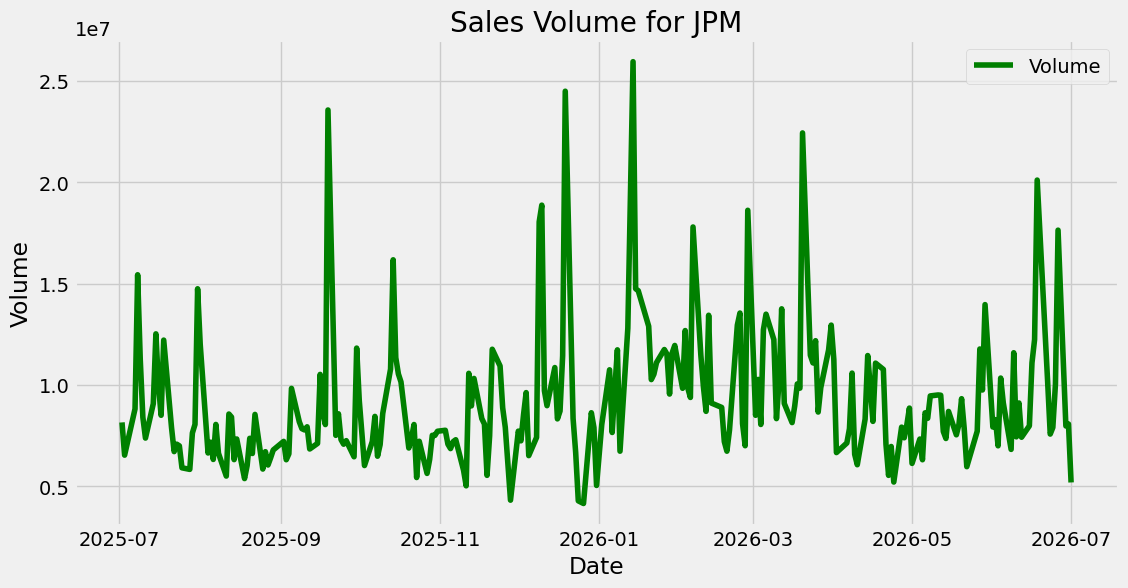

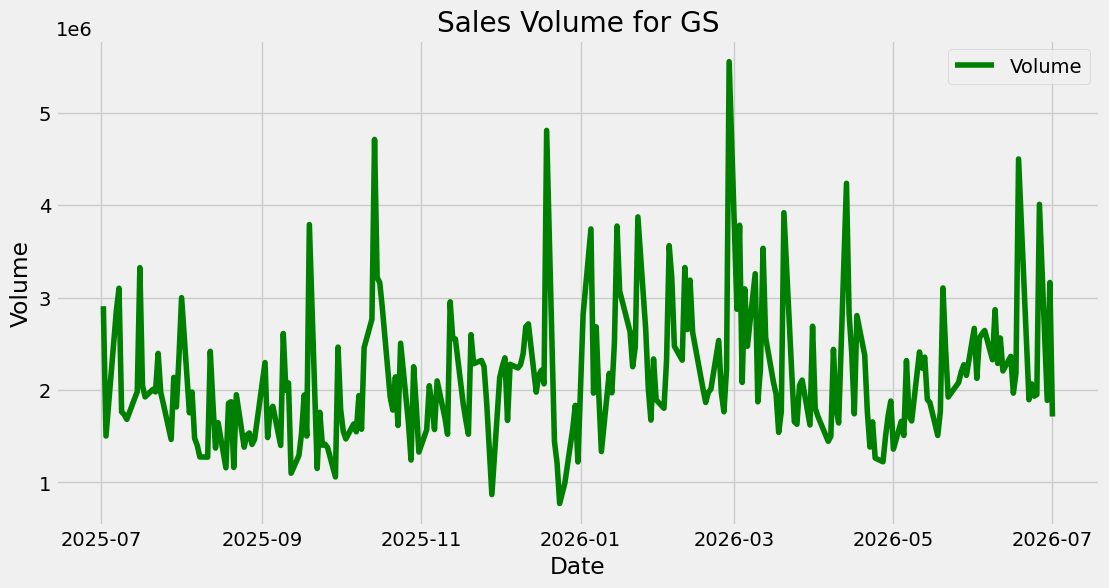

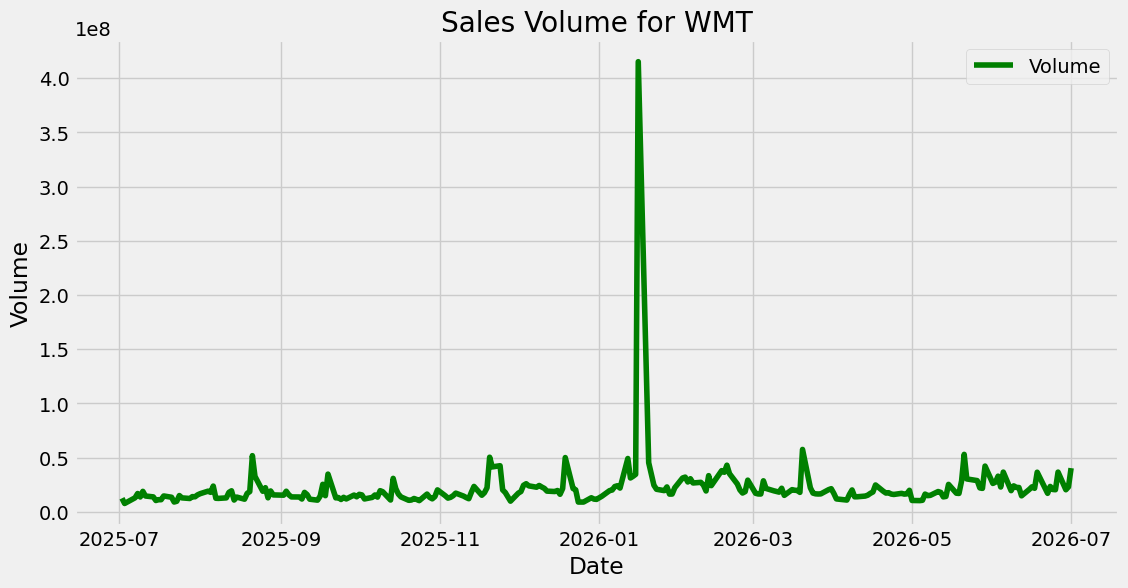

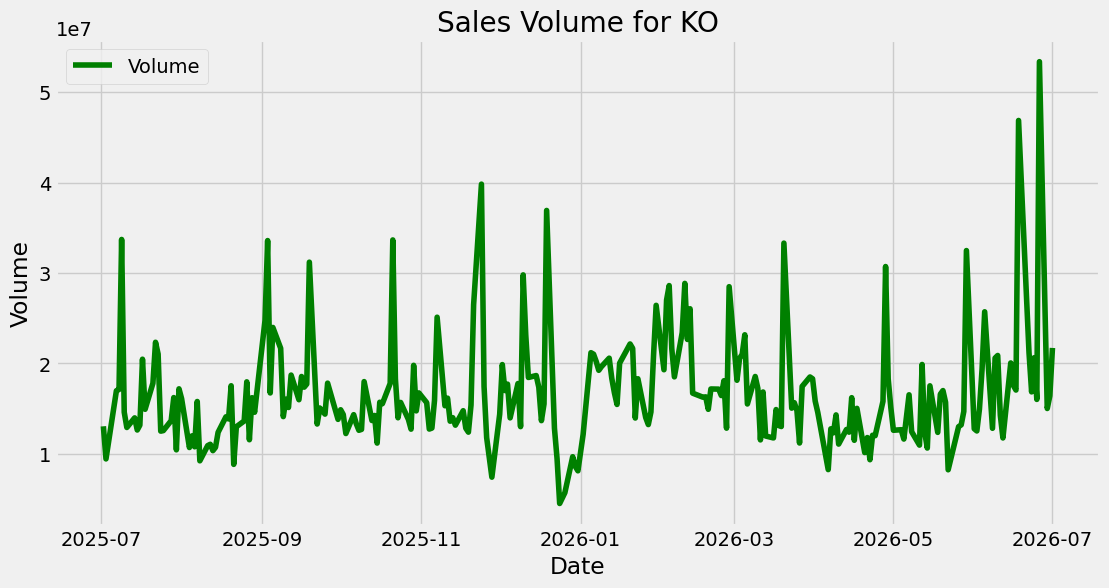

In [11]:
for symbol, df in company_data.items():
  plt.figure(figsize=(12,6))
  plt.plot(df.index, df['Volume'], label='Volume', color='green')
  plt.xlabel('Date')
  plt.ylabel('Volume')
  plt.legend()
  plt.title(f'Sales Volume for {symbol}')
  plt.grid(True)
  plt.show()

## Step 9: Stock Price Movement Analysis

This section visualizes stock movement trends for each company.

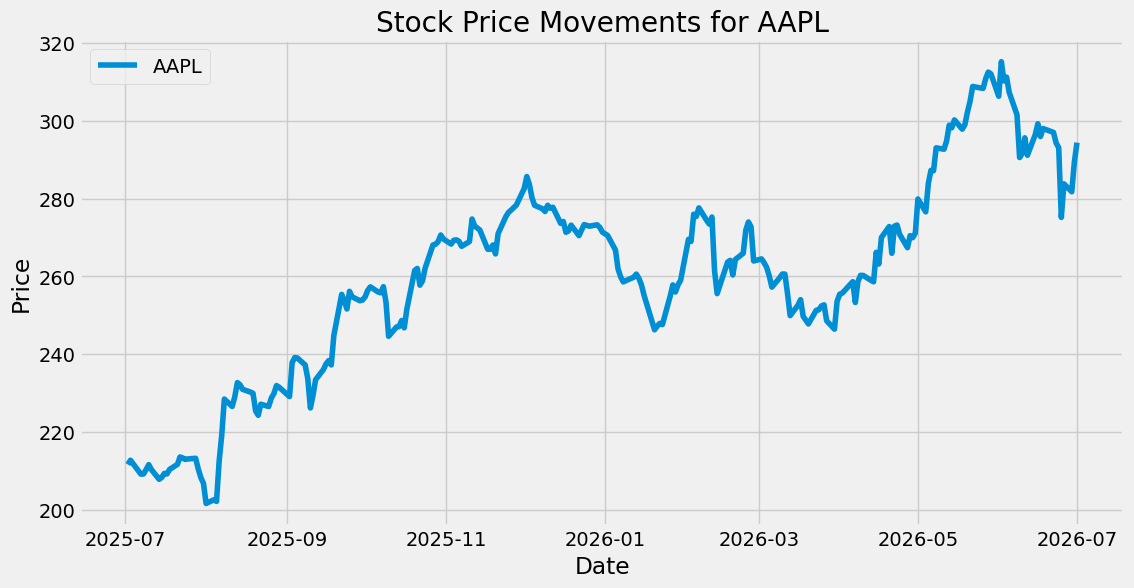

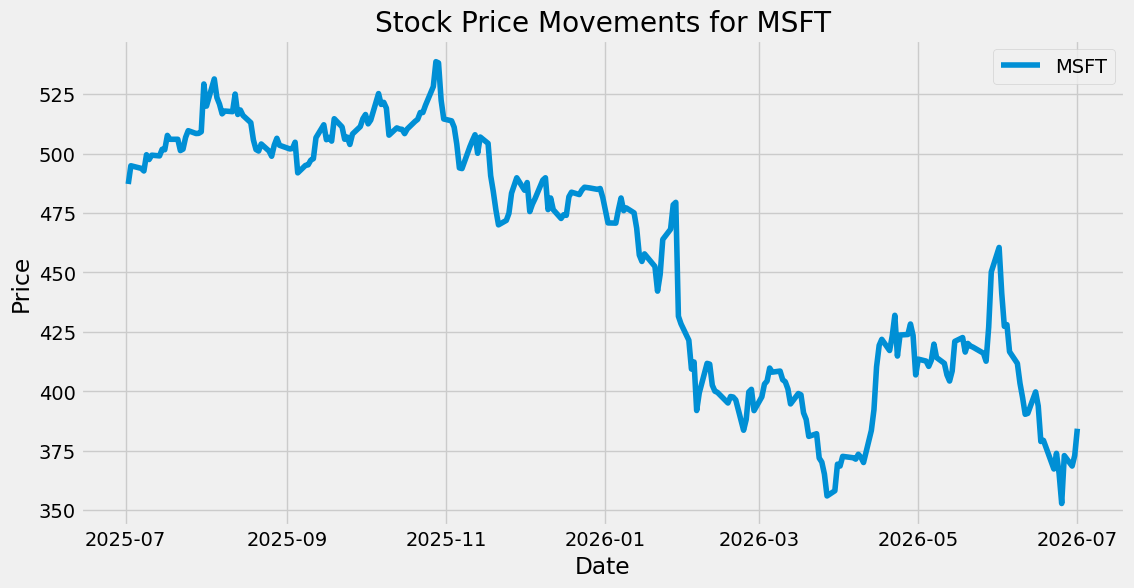

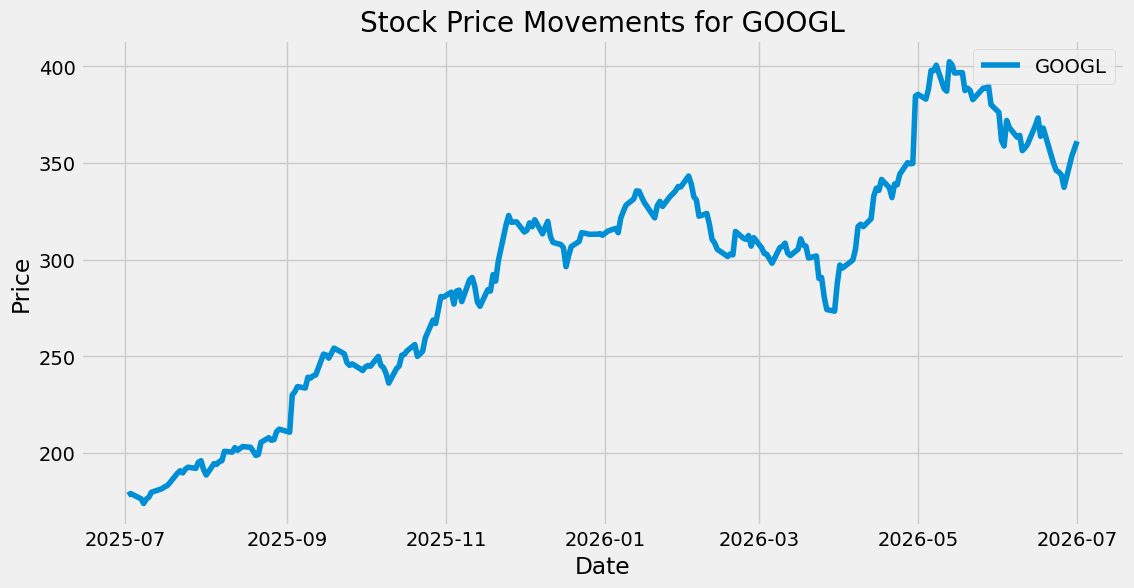

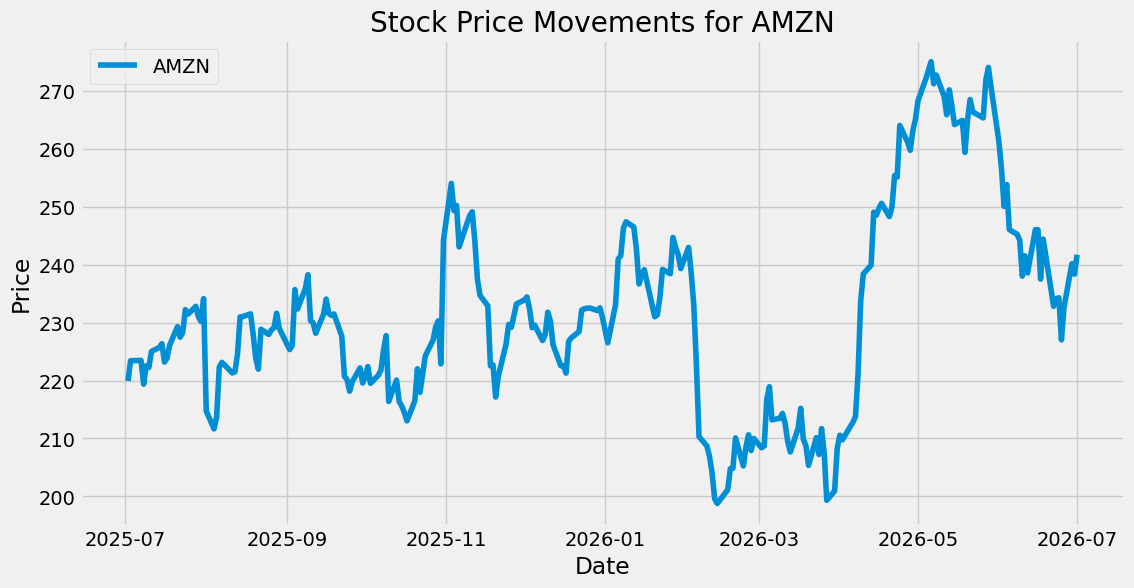

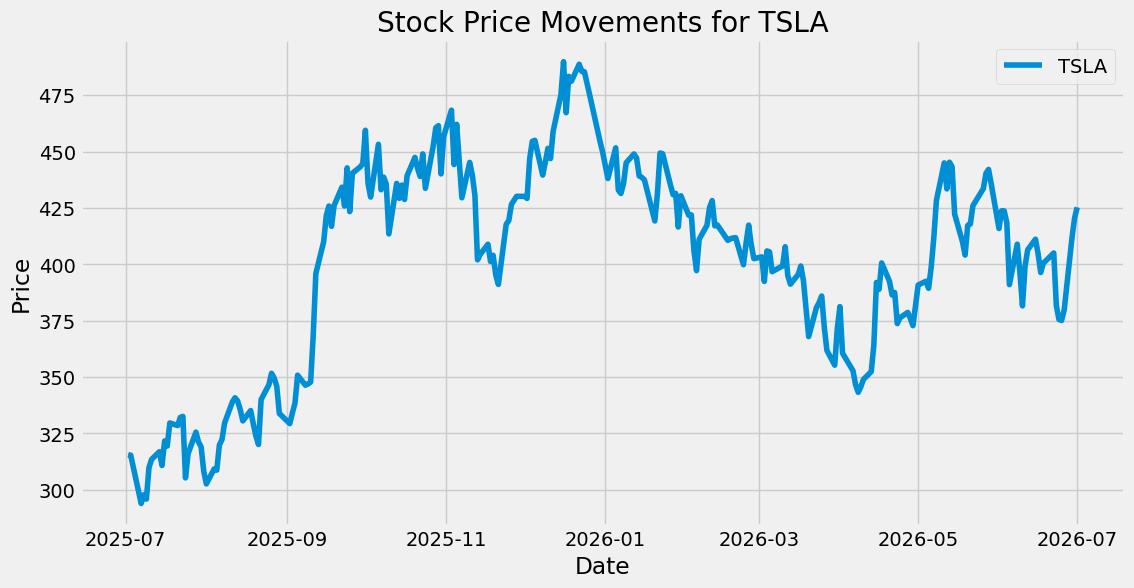

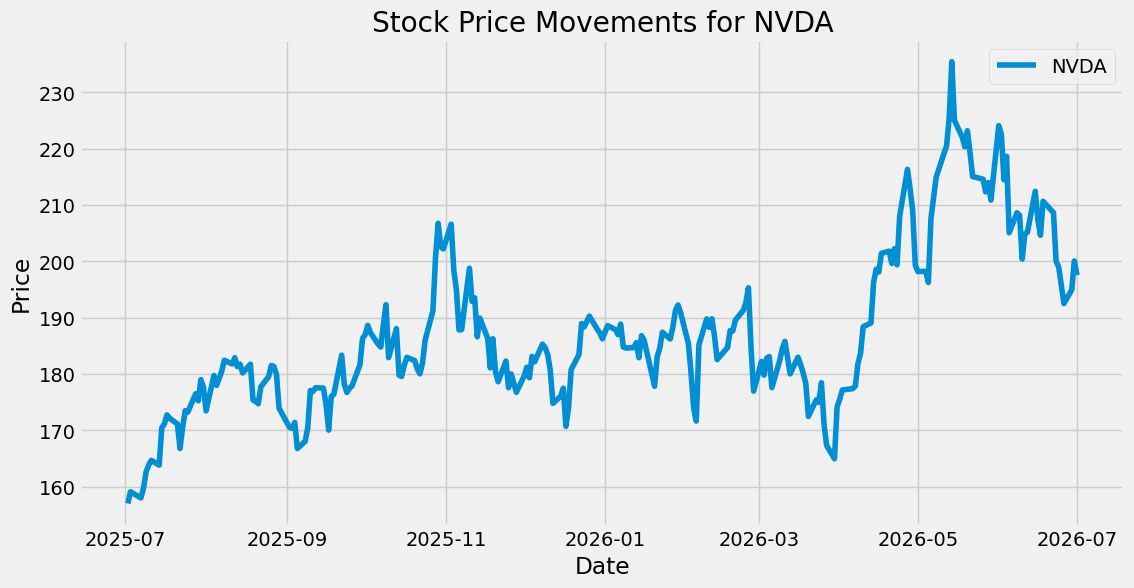

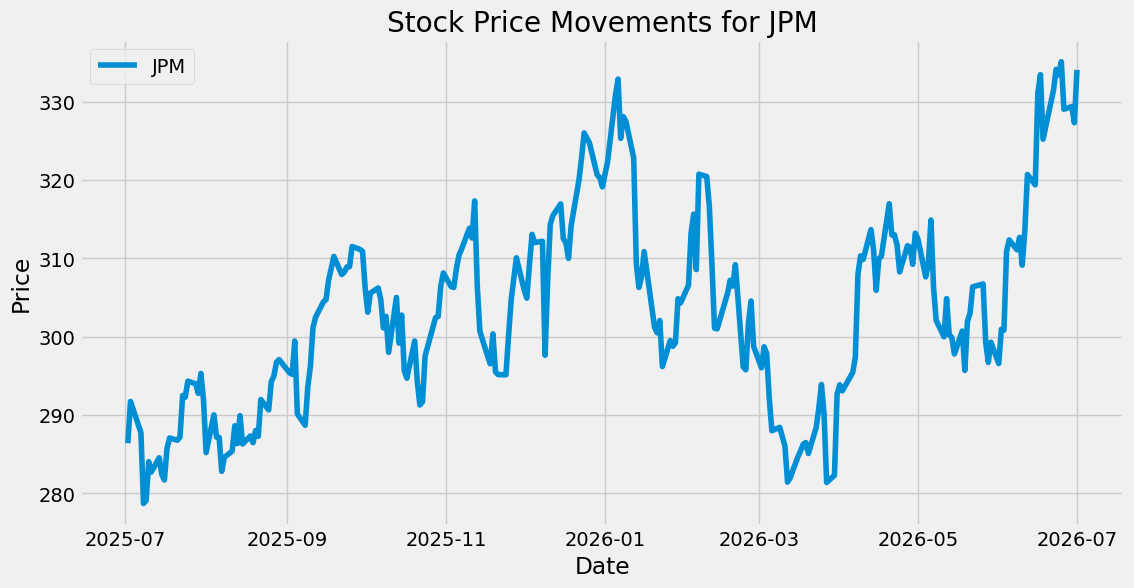

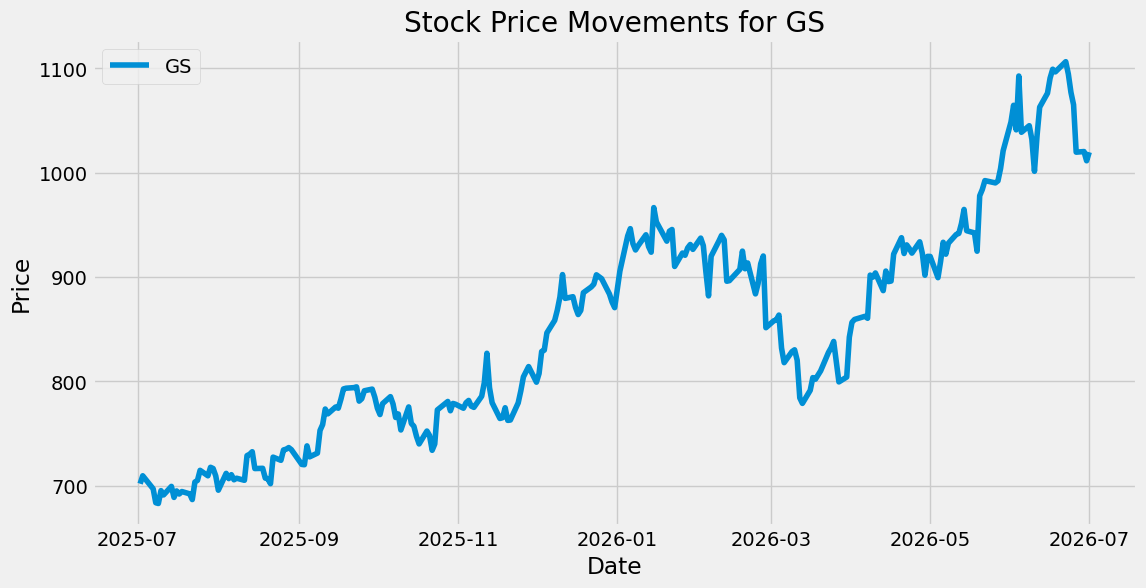

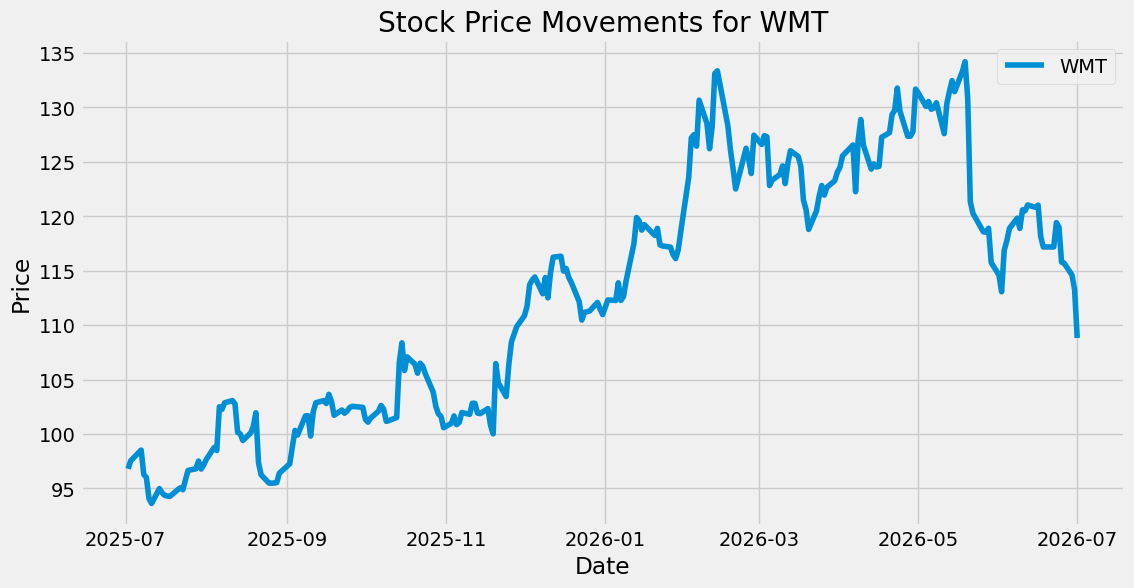

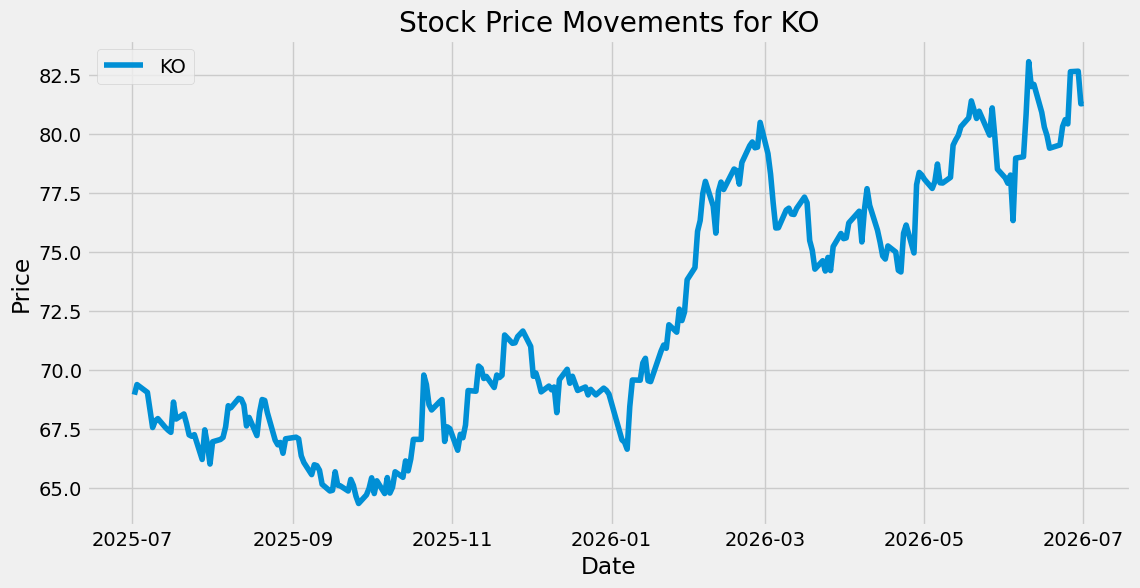

In [12]:
for symbol, df in company_data.items():
  plt.figure(figsize=(12,6))
  plt.plot(df.index, df['Close'], label=symbol)
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()
  plt.title(f'Stock Price Movements for {symbol}')
  plt.grid(True)
  plt.show()

## Step 10: Risk vs Return Analysis

Risk and return are important factors in stock market analysis.

- Return = Expected profit
- Risk = Price volatility

This scatter plot compares all selected companies based on:
- Expected Return
- Risk

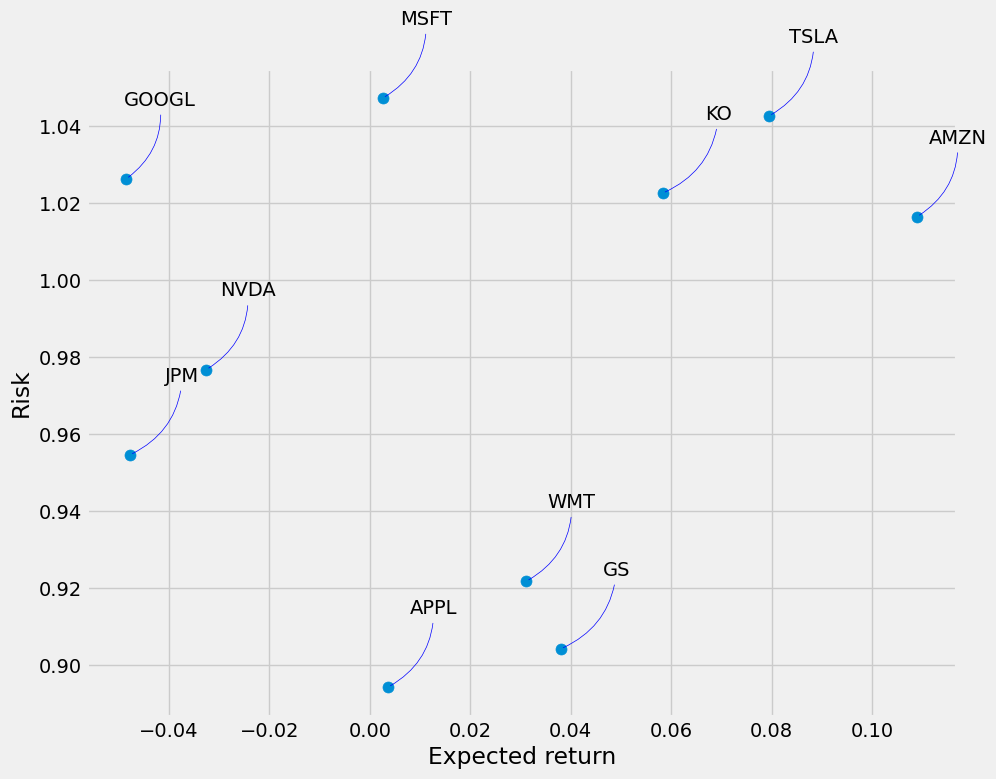

In [13]:
np.random.seed(42)
data= np.random.randn(100,10)
tech_rets = pd.DataFrame(data, columns=['APPL','MSFT','GOOGL','AMZN','TSLA','NVDA','JPM','GS','WMT','KO'])
rets =tech_rets.dropna()
area = np.pi*20
plt.figure(figsize=(10,8))
plt.scatter(rets.mean(),rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label,x,y in zip(rets.columns, rets.mean(), rets.std()):
  plt.annotate(label, xy=(x,y), xytext=(50,50), textcoords='offset points', ha='right', va='bottom',
               arrowprops=dict(arrowstyle='-',color='blue',connectionstyle='arc3,rad=-0.3'))

plt.show()

## Step 11: Next Day Stock Price Prediction

Using the trained Linear Regression model, we predict the next day closing price for each company.

In [14]:
for symbol, model in company_models.items():
  latest_closing_price = company_data[symbol]['Close'].iloc[-1]
  latest_data = pd.DataFrame({'Close': [latest_closing_price]})
  predicted_price = model.predict(latest_data)
  print(f"Predicted Price for {symbol} on the next day: {predicted_price[0]}")

Predicted Price for AAPL on the next day: [294.11443114]
Predicted Price for MSFT on the next day: [384.5081057]
Predicted Price for GOOGL on the next day: [360.83594832]
Predicted Price for AMZN on the next day: [241.25901242]
Predicted Price for TSLA on the next day: [424.82308587]
Predicted Price for NVDA on the next day: [197.14538353]
Predicted Price for JPM on the next day: [332.28288715]
Predicted Price for GS on the next day: [1017.88018156]
Predicted Price for WMT on the next day: [108.96654577]
Predicted Price for KO on the next day: [81.35726839]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has fea

# Conclusion

This project successfully analyzed real-time stock market data for 10 major companies.

### Key Insights
- Stock prices vary significantly across sectors.
- Technology companies showed higher volatility.
- Risk and return analysis helped compare investment opportunities.
- Linear Regression provided basic next-day stock price prediction.

### Future Improvements
- Use advanced ML models (LSTM, ARIMA)
- Add technical indicators
- Improve prediction accuracy using more features